In [42]:
import pandas as pd
from jarvis.db.figshare import data
from matminer.featurizers.composition import ElementProperty
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, r2_score
import matplotlib.pyplot as plt


In [43]:
mxene_data = data("mxene275")
df = pd.DataFrame(mxene_data)

# Buat kolom formula dari id
df["formula"] = df["id"].str.replace("POSCAR-", "").str.replace(".vasp", "")

print(df[["id", "formula", "formation_energy"]].head())


Obtaining mxene dataset 275...
Reference:https://cmr.fysik.dtu.dk/c2db/c2db.html
Loading the zipfile...
Loading completed.
                     id   formula  formation_energy
0      POSCAR-Cr2C.vasp      Cr2C          0.789144
1    POSCAR-Cr2CO2.vasp    Cr2CO2         -0.881747
2    POSCAR-Cr2F2N.vasp    Cr2F2N         -1.503967
3  POSCAR-Cr2H2NO2.vasp  Cr2H2NO2         -0.893623
4      POSCAR-Cr2N.vasp      Cr2N          0.531967


In [44]:
from pymatgen.core import Composition
from matminer.featurizers.composition import ElementProperty

# Buat kolom Composition dari formula string
df["composition"] = df["formula"].apply(lambda x: Composition(x))

# Gunakan preset Magpie untuk ekstraksi fitur elemental
ep = ElementProperty.from_preset(preset_name="magpie")
features = ep.featurize_dataframe(df, "composition", ignore_errors=True)

features.head()


ElementProperty: 100%|█████████████████████████████████████████████████████████████| 275/275 [00:00<00:00, 1080.84it/s]


,id,atoms,formation_energy,formula,composition,MagpieData minimum Number,MagpieData maximum Number,MagpieData range Number,MagpieData mean Number,MagpieData avg_dev Number,...,MagpieData range GSmagmom,MagpieData mean GSmagmom,MagpieData avg_dev GSmagmom,MagpieData mode GSmagmom,MagpieData minimum SpaceGroupNumber,MagpieData maximum SpaceGroupNumber,MagpieData range SpaceGroupNumber,MagpieData mean SpaceGroupNumber,MagpieData avg_dev SpaceGroupNumber,MagpieData mode SpaceGroupNumber
0,POSCAR-Cr2C.vasp,"{'lattice_mat': [[2.8339622740702017, 0.0, 0.0...",0.789144,Cr2C,"(Cr, C)",6.0,24.0,18.0,18.000000,8.000000,...,0.0,0.0,0.0,0.0,194.0,229.0,35.0,217.333333,15.555556,229.0
1,POSCAR-Cr2CO2.vasp,"{'lattice_mat': [[2.907555450889736, 0.0, 0.0]...",-0.881747,Cr2CO2,"(Cr, C, O)",6.0,24.0,18.0,14.000000,8.000000,...,0.0,0.0,0.0,0.0,12.0,229.0,217.0,135.200000,98.560000,12.0
2,POSCAR-Cr2F2N.vasp,"{'lattice_mat': [[3.01599619423943, 0.0, 0.0],...",-1.503967,Cr2F2N,"(Cr, F, N)",7.0,24.0,17.0,14.600000,7.520000,...,0.0,0.0,0.0,0.0,15.0,229.0,214.0,136.400000,97.120000,15.0
3,POSCAR-Cr2H2NO2.vasp,"{'lattice_mat': [[3.036845057830191, 0.0, 0.0]...",-0.893623,Cr2H2NO2,"(Cr, H, N, O)",1.0,24.0,23.0,10.428571,7.755102,...,0.0,0.0,0.0,0.0,12.0,229.0,217.0,152.000000,80.000000,12.0
4,POSCAR-Cr2N.vasp,"{'lattice_mat': [[2.675420297353982, 0.0, 0.0]...",0.531967,Cr2N,"(Cr, N)",7.0,24.0,17.0,18.333333,7.555556,...,0.0,0.0,0.0,0.0,194.0,229.0,35.0,217.333333,15.555556,229.0


In [45]:
# Ambil hanya kolom numerik, lalu buang kolom target
X = features.select_dtypes(include=["number"]).drop(columns=["formation_energy"])
y = features["formation_energy"]

from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)


In [46]:
model = RandomForestRegressor(n_estimators=200, random_state=42)
model.fit(X_train, y_train)

y_pred = model.predict(X_test)

print("MAE:", mean_absolute_error(y_test, y_pred))
print("R²:", r2_score(y_test, y_pred))


MAE: 0.1131325364939998
R²: 0.9713124906633126


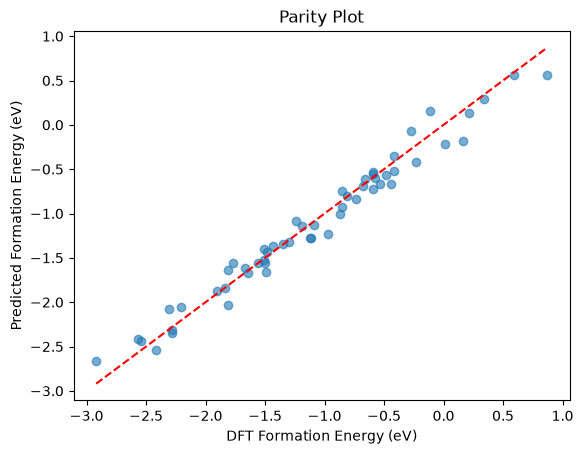

In [47]:
plt.scatter(y_test, y_pred, alpha=0.6)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--')
plt.xlabel("DFT Formation Energy (eV)")
plt.ylabel("Predicted Formation Energy (eV)")
plt.title("Parity Plot")
plt.show()


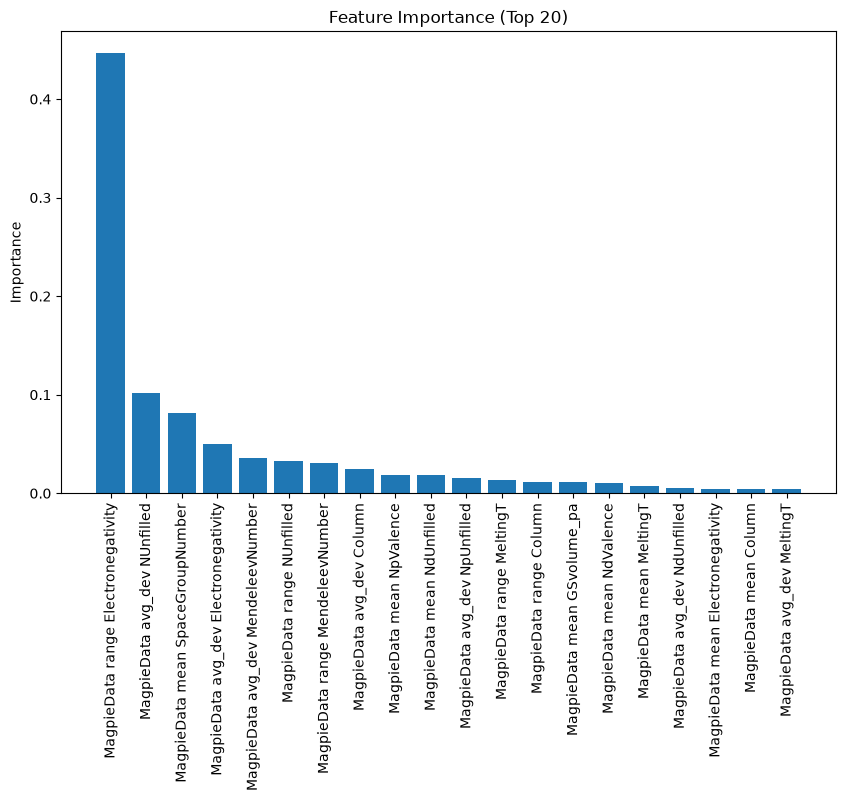

In [48]:
import numpy as np

# Ambil importance dari model Random Forest
importances = model.feature_importances_
indices = np.argsort(importances)[::-1]

# Plot 20 fitur teratas
plt.figure(figsize=(10,6))
plt.title("Feature Importance (Top 20)")
plt.bar(range(20), importances[indices[:20]], align="center")
plt.xticks(range(20), X_train.columns[indices[:20]], rotation=90)
plt.ylabel("Importance")
plt.show()


In [49]:
from sklearn.model_selection import GroupKFold, cross_val_score

# Ambil grup berdasarkan logam M dari formula (misalnya huruf pertama)
groups = df["formula"].str.extract(r"([A-Z][a-z]?)")[0]

gkf = GroupKFold(n_splits=5)
scores = cross_val_score(model, X, y, cv=gkf, groups=groups, scoring="r2")

print("R² per fold:", scores)
print("Mean R²:", scores.mean())


R² per fold: [0.94125267 0.90852123 0.90872817 0.85441987 0.80287807]
Mean R²: 0.8831600007970197


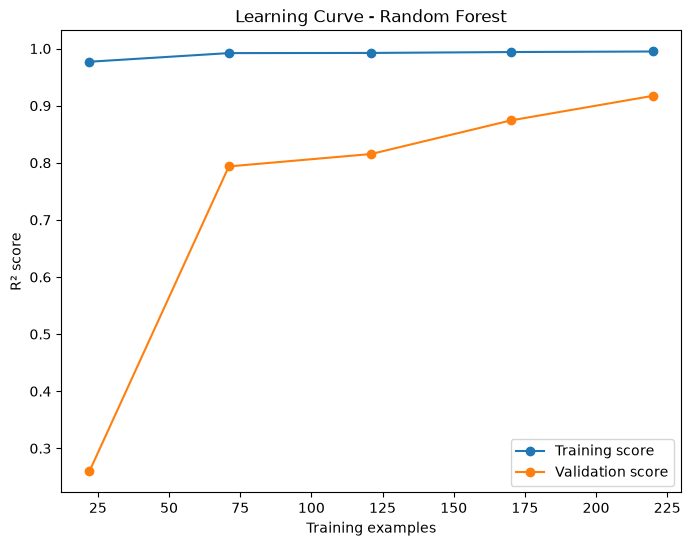

In [50]:
from sklearn.model_selection import learning_curve

train_sizes, train_scores, test_scores = learning_curve(
    model, X, y, cv=5, scoring="r2", n_jobs=-1
)

plt.figure(figsize=(8,6))
plt.plot(train_sizes, train_scores.mean(axis=1), "o-", label="Training score")
plt.plot(train_sizes, test_scores.mean(axis=1), "o-", label="Validation score")
plt.xlabel("Training examples")
plt.ylabel("R² score")
plt.title("Learning Curve - Random Forest")
plt.legend()
plt.show()


In [51]:
import os

# Buat folder jika belum ada
os.makedirs("data/processed", exist_ok=True)

# Simpan hasil prediksi
pred_df.to_csv("data/processed/predictions.csv", index=False)


In [52]:
# Simpan hasil prediksi dari tahap 3
pred_df = pd.DataFrame({
    "formula": df["formula"].iloc[y_test.index],   # formula dari test set
    "formation_energy_true": y_test,
    "formation_energy_pred": y_pred
})

pred_df.to_csv("data/processed/predictions.csv", index=False)


In [53]:
# Prediksi untuk seluruh dataset
y_all_pred = model.predict(X)

pred_all_df = pd.DataFrame({
    "formula": df["formula"],
    "formation_energy_true": y,
    "formation_energy_pred": y_all_pred
})

import os
os.makedirs("data/processed", exist_ok=True)
pred_all_df.to_csv("data/processed/predictions_all.csv", index=False)


In [54]:
import joblib
import os

os.makedirs("src", exist_ok=True)  # buat folder src kalau belum ada
joblib.dump(model, "src/model_rf.joblib")


['src/model_rf.joblib']

In [55]:
def predict_formation_energy(formula_str):
    comp = Composition(formula_str)
    row = pd.DataFrame({"composition": [comp]})
    row_feat = ep.featurize_dataframe(row, "composition", ignore_errors=True)
    X_new = row_feat[model.feature_names_in_]
    return model.predict(X_new)[0]